### Scalable Speech Recognition Training Pipeline

Title:
Optimized Large-Scale Speech Recognition Training Framework

Short Description:
This code implements a comprehensive pipeline for efficient large-scale speech recognition training. It features dataset caching, dynamic bucketing, memory-optimized transformer blocks, and robust training procedures to handle LibriSpeech datasets while minimizing memory usage and maximizing computational efficiency.

Key Libraries Used:

    torch/torchaudio: Core deep learning and audio processing

    pickle: Dataset caching for faster reloads

    os/string: File handling and character mapping

    numpy: Numerical operations

Code Logic and Flow

High-Level Overview:
The pipeline processes LibriSpeech audio through mel-spectrogram conversion with caching, implements dynamic sequence bucketing for efficient batching, uses memory-optimized transformer blocks, and trains with CTC loss using gradient accumulation. It includes comprehensive error handling and performance monitoring throughout.

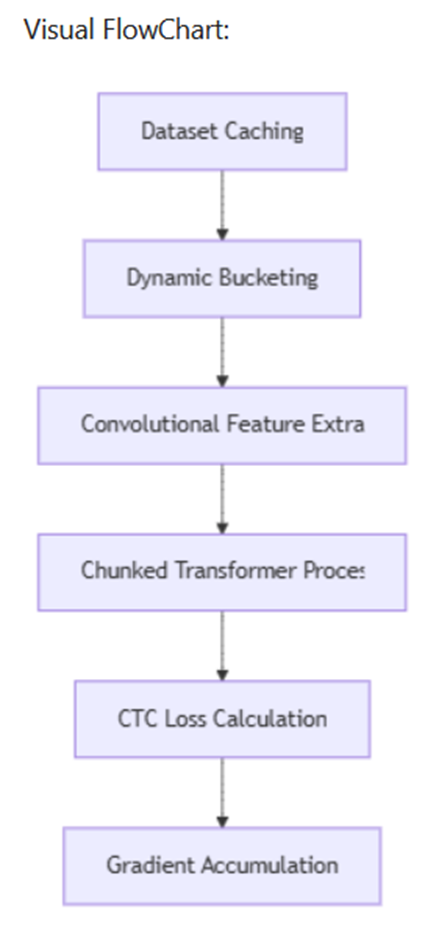

Step-by-Step Code Breakdown

Step 1: Optimized Dataset Handling

    Caching System:

        Precomputes and stores mel-spectrograms as pickle files

        Automatically reloads cached features on subsequent runs

    Audio Processing:

        Converts stereo to mono

        Resamples to 16kHz

        Computes 80-band mel-spectrograms

        Filters excessively long audio samples

    Text Processing:

        Creates character mapping with CTC blank token

        Converts transcripts to numerical sequences

        Handles empty transcripts gracefully

Step 2: Dynamic Batching System

    Bucketing Algorithm:

        Groups samples by similar audio lengths

        Uses configurable bucket size factor (default: 160 frames)

        Pads sequences to bucket size instead of max length

    Efficiency Features:

        Sorts sequences by length for optimal padding

        Filters invalid samples during collation

        Implements time tracking for performance tuning

Step 3: Memory-Efficient Model

    Convolutional Frontend:

        Two strided 1D convolutions for downsampling

        Outputs 128-dimensional features

    Transformer Encoder:

        4-layer chunked transformer blocks

        128-dimensional embeddings with 4 attention heads

        Implements chunked attention (160-frame segments)

        Uses gradient checkpointing for feedforward blocks

    Output Head:

        Linear projection to character probabilities

        Includes CTC blank token

Step 4: Robust Training Loop

    Gradient Accumulation:

        Accumulates gradients over 2 batches

        Enables larger effective batch sizes

    Loss Handling:

        Implements CTC loss with zero_infinity

        Validates sequence lengths before loss calculation

        Skips batches with invalid length configurations

    Checkpointing:

        Saves model after each epoch

        Maintains separate directory for trained models

    Performance Monitoring:

        Tracks dataset initialization time

        Measures per-item loading time

        Times collation and batch processing

Connecting to the Lecture**

    Memory Optimization: Chunked attention and checkpointing enable larger models

    Dataset Efficiency: Caching dramatically reduces preprocessing overhead

    Dynamic Batching: Bucketing minimizes padding waste

    Robust Training: Comprehensive error handling prevents crash failures

    Resource Management: Sample limits enable prototyping on resource-constrained systems

    Sequence Length Handling: Explicit checks prevent CTC numerical instability

    Performance Monitoring: Timing metrics help identify bottlenecks

    Model Preservation: Regular checkpointing protects against interruptions

    Efficient Convolutions: Strided convolutions reduce sequence length

    Character-Level Modeling: Compact alphabet simplifies output space

    Scalability Design: Modular components allow incremental scaling

    Real-World Adaptation: Handles dataset inconsistencies and missing files




In [15]:

import os
import torch
import torch.nn as nn
import torchaudio
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint
import string
import time
import pickle
import traceback

# Constants
n_mels = 80
alphabet = string.ascii_lowercase + " '"
char_to_idx = {c: i+1 for i, c in enumerate(alphabet)}  # 0 is reserved for CTC blank

# Preprocessing function
def text_to_sequence(text):
    text = text.lower().strip()
    seq = []
    for c in text:
        if c in char_to_idx:
            seq.append(char_to_idx[c])
    if not seq:  # Handle empty sequences
        return torch.tensor([0], dtype=torch.long)
    return torch.tensor(seq, dtype=torch.long)

# Custom Dataset for LibriSpeech dev-clean
class MyLibriSpeechDataset(Dataset):
    def __init__(self, root, max_samples=50, cache_dir=None, n_mels=80, max_audio_len=16000 * 10):
        self.root = root
        self.cache_dir = cache_dir
        self.n_mels = n_mels
        self.max_audio_len = max_audio_len
        self.samples = []
        self.transcripts = {}
        if cache_dir:
            os.makedirs(cache_dir, exist_ok=True)
        
        start_time = time.time()
        # Parse transcript files
        for dirpath, _, filenames in os.walk(root):
            for fname in filenames:
                if fname.endswith('.trans') or fname.endswith('.trans.txt'):
                    trans_path = os.path.join(dirpath, fname)
                    with open(trans_path, 'r', encoding='utf-8') as f:
                        for line in f:
                            parts = line.strip().split(' ', 1)
                            if len(parts) == 2:
                                utt_id, text = parts
                                utt_id = utt_id.strip().lower()
                                self.transcripts[utt_id] = text
        print("Transcript keys:", list(self.transcripts.keys())[:5])
        
        # Find and process .flac files
        for dirpath, _, filenames in os.walk(root):
            for fname in filenames:
                if fname.endswith('.flac') and len(self.samples) < max_samples:
                    utt_id = os.path.splitext(fname)[0].strip().lower()
                    audio_path = os.path.join(dirpath, fname)
                    if utt_id in self.transcripts:
                        cache_path = os.path.join(self.cache_dir, f"{utt_id}.pkl") if self.cache_dir else None
                        
                        # Try to load from cache
                        if cache_path and os.path.exists(cache_path):
                            try:
                                with open(cache_path, 'rb') as f:
                                    mel, text_seq = pickle.load(f)
                                # Ensure text_seq is tensor
                                if isinstance(text_seq, list):
                                    text_seq = torch.tensor(text_seq, dtype=torch.long)
                            except Exception as e:
                                print(f"Error loading cache {cache_path}: {e}")
                                cache_path = None  # Reprocess this file
                        
                        # Process if not cached
                        if not cache_path or not os.path.exists(cache_path):
                            try:
                                waveform, sr = torchaudio.load(audio_path)
                                if waveform.size(-1) > self.max_audio_len:
                                    print(f"Skipping {audio_path}: too long")
                                    continue
                                mel = self.compute_mel(waveform, sr)
                                text = self.transcripts[utt_id]
                                text_seq = text_to_sequence(text)
                                    
                                if cache_path:
                                    with open(cache_path, 'wb') as f:
                                        pickle.dump((mel, text_seq), f)
                            except Exception as e:
                                print(f"Error processing {audio_path}: {e}")
                                continue
                        # Check text sequence length
                        text_len = text_seq.numel()
                        audio_len = mel.size(0) * 16000 / 400
                        if text_len > 0:
                            self.samples.append((mel, text_seq, audio_path))
                        else:
                            print(f"Skipping sample {audio_path}: empty transcript")
                    else:
                        print(f"Transcript not found for: {audio_path}")
        print(f"Total samples found: {len(self.samples)}")
        print(f"Dataset initialization time: {time.time() - start_time:.2f}s")
    
    def compute_mel(self, wav, sr):
        if wav.dim() > 1:
            wav = wav.mean(dim=0, keepdim=True)
        if sr != 16000:
            wav = torchaudio.transforms.Resample(sr, 16000)(wav)
        mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=16000, n_mels=self.n_mels, n_fft=1024, hop_length=256, f_max=8000
        )
        mel = mel_transform(wav)  # (1, n_mels, time)
        mel = mel.squeeze(0).transpose(0, 1)  # (time, n_mels)
        return mel

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        start_time = time.time()
        mel, text_seq, audio_path = self.samples[idx]
        print(f"Dataset getitem time for {audio_path}: {time.time() - start_time:.2f}s")
        return mel, text_seq

# Simplified Dataset
class AugmentedDataset(Dataset):
    def __init__(self, dataset, max_samples=50):
        self.dataset = dataset
        self.max_samples = min(max_samples, len(dataset))
        
    def __len__(self):
        return self.max_samples

    def __getitem__(self, idx):
        return self.dataset[idx]

# Dynamic Batching Collator
class BucketingCollator:
    def __init__(self, factor=160, max_len=2500):  # ~10s audio after mel transform
        self.factor = factor
        self.max_len = max_len

    def __call__(self, batch):
        start_time = time.time()
        # Filter out None items
        valid_batch = [item for item in batch if item is not None]
        if not valid_batch:
            return None, None, None
            
        # Sort by mel length
        valid_batch.sort(key=lambda x: x[0].shape[0], reverse=True)
        mels, text_seqs = zip(*valid_batch)
        
        # Filter out sequences longer than max_len
        valid_mels = []
        valid_text_seqs = []
        for mel, text_seq in zip(mels, text_seqs):
            if mel.shape[0] <= self.max_len and text_seq.numel() > 0:
                valid_mels.append(mel)
                valid_text_seqs.append(text_seq)
            else:
                print(f"Skipping sample: mel length {mel.shape[0]} or text length {text_seq.numel()} invalid")
        
        if not valid_mels:
            print(f"Collate time: {time.time() - start_time:.2f}s")
            return None, None, None
        
        # Pad mels to bucket size
        max_mel_len = max(m.shape[0] for m in valid_mels)
        bucket_size = min(((max_mel_len // self.factor) + 1) * self.factor, self.max_len)
        mels_padded = torch.zeros(len(valid_mels), n_mels, bucket_size)
        for i, mel in enumerate(valid_mels):
            # Transpose to (n_mels, time)
            mel_t = mel.permute(1, 0)
            mels_padded[i, :, :mel_t.shape[1]] = mel_t[:, :bucket_size]
        
        # Pad text sequences
        text_lens = torch.tensor([seq.numel() for seq in valid_text_seqs])
        max_text_len = max(text_lens)
        text_padded = torch.zeros((len(valid_text_seqs), max_text_len), dtype=torch.long)
        for i, seq in enumerate(valid_text_seqs):
            text_padded[i, :seq.numel()] = seq
            
        print(f"Collate time: {time.time() - start_time:.2f}s")
        return mels_padded, text_padded, text_lens

# Memory-Efficient Transformer Block
class EfficientTransformerBlock(nn.Module):
    def __init__(self, d_model, nhead, chunk_size=160):
        super().__init__()
        self.chunk_size = chunk_size
        self.attn = nn.MultiheadAttention(d_model, nhead, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4*d_model),
            nn.GELU(),
            nn.Linear(4*d_model, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def chunked_attention(self, x):
        chunks = x.split(self.chunk_size, 1)
        attn_out = []
        for chunk in chunks:
            attn, _ = self.attn(chunk, chunk, chunk)
            attn_out.append(attn)
        return torch.cat(attn_out, dim=1)

    def forward(self, x):
        x = self.norm1(x + self.chunked_attention(x))
        x = checkpoint(self._ffn_block, x)
        return x

    def _ffn_block(self, x):
        return self.norm2(x + self.ffn(x))

# Simple Speech Model
class SimpleSpeechModel(nn.Module):
    def __init__(self, layers=4, d_model=128, nhead=4, n_mels=80):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_mels, 64, kernel_size=10, stride=2, padding=4),
            nn.ReLU(),
            nn.Conv1d(64, d_model, kernel_size=8, stride=1, padding=4),
        )
        self.encoder = nn.ModuleList([
            EfficientTransformerBlock(d_model, nhead)
            for _ in range(layers)
        ])
        self.head = nn.Linear(d_model, len(char_to_idx) + 1)  # +1 for CTC blank

    def forward(self, x):
        x = self.conv(x)  # (batch, d_model, time)
        x = x.permute(0, 2, 1)  # (batch, time, d_model)
        for layer in self.encoder:
            x = layer(x)
        return self.head(x)

# Initialize components
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = SimpleSpeechModel(layers=4, d_model=128, n_mels=n_mels).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)
accum_steps = 2

# Load dataset
DATA_DIR = r"C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\7 Challenges and Future Directions in SpeechLM Research\7.3 Scaling to Larger Models and Datasets\LibriSpeech\dev-clean"
CACHE_DIR = os.path.join(DATA_DIR, "cache")
dataset = MyLibriSpeechDataset(DATA_DIR, max_samples=50, cache_dir=CACHE_DIR)
aug_dataset = AugmentedDataset(dataset, max_samples=50)
loader = DataLoader(
    aug_dataset,
    batch_size=2,
    collate_fn=BucketingCollator(),
    num_workers=0,
    pin_memory=True,
    shuffle=True
)

# Training loop
os.makedirs(os.path.join(DATA_DIR, "trained_model"), exist_ok=True)
for epoch in range(5):
    print(f"Starting epoch {epoch}")
    model.train()
    accum_loss = 0.0
    batch_count = 0
    
    for i, batch in enumerate(loader):
        start_time = time.time()
        if batch is None or batch[0] is None:
            print(f"    Skipping batch {i}: empty batch")
            continue
            
        mels, text_padded, text_lens = batch
        try:
            # Move data to device
            mels = mels.to(device)
            text_padded = text_padded.to(device)
            text_lens = text_lens.to(device)
            
            # Forward pass
            outputs = model(mels)  # (batch, time, vocab_size)
            log_probs = torch.log_softmax(outputs, dim=-1)
            
            # Calculate input lengths (time dimension after model)
            input_lengths = torch.full(
                (mels.size(0),), 
                outputs.size(1),  # Actual output sequence length
                dtype=torch.long, 
                device=device
            )
            
            # Validate lengths
            if any(text_lens == 0) or any(input_lengths <= text_lens):
                print(f"    Skipping batch {i}: invalid lengths (input_lengths={input_lengths.tolist()}, text_lens={text_lens.tolist()})")
                continue
                
            # CTC loss calculation
            loss = ctc_loss(
                log_probs.permute(1, 0, 2),  # (time, batch, vocab_size)
                text_padded,
                input_lengths,
                text_lens
            )
            
            # Backward pass with gradient accumulation
            loss.backward()
            accum_loss += loss.item()
            batch_count += 1
            
            # Update weights
            if (i + 1) % accum_steps == 0 or (i + 1) == len(loader):
                optimizer.step()
                optimizer.zero_grad()
                
                avg_loss = accum_loss / batch_count if batch_count > 0 else 0.0
                print(f"    Epoch {epoch} | Batch {i} | Avg Loss: {avg_loss:.4f}")
                accum_loss = 0.0
                batch_count = 0
            else:
                print(f"    Epoch {epoch} | Batch {i} | Loss: {loss.item():.4f}")
            
            print(f"    Batch time: {time.time() - start_time:.2f}s")
            
        except Exception as e:
            print(f"    Error in epoch {epoch}, batch {i}: {e}")
            print(traceback.format_exc())
            optimizer.zero_grad()
            continue
    
    # Save model
    model_path = os.path.join(r"C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\7 Challenges and Future Directions in SpeechLM Research\7.3 Scaling to Larger Models and Datasets", "trained_model_exercise", f"speechlm_epoch_{epoch}.pt")
    torch.save(model.state_dict(), model_path)
    print(f"    Saved model to {model_path}")

Using device: cpu
Parameters: 0.9M
Transcript keys: ['1272-128104-0000', '1272-128104-0001', '1272-128104-0002', '1272-128104-0003', '1272-128104-0004']
Skipping C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\7 Challenges and Future Directions in SpeechLM Research\7.3 Scaling to Larger Models and Datasets\LibriSpeech\dev-clean\1272\128104\1272-128104-0002.flac: too long
Skipping C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\7 Challenges and Future Directions in SpeechLM Research\7.3 Scaling to Larger Models and Datasets\LibriSpeech\dev-clean\1272\128104\1272-128104-0004.flac: too long
Skipping C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\7 Challenges and Future Directions in SpeechLM Research\7.3 Scaling to Larger Models and Datasets\LibriSpeech\dev-clean\1272\128104\1272-128104-0009.flac: too long
Skipping C:\Users\vinit_hqjv9wt\Desktop\Fin